# Class merging

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

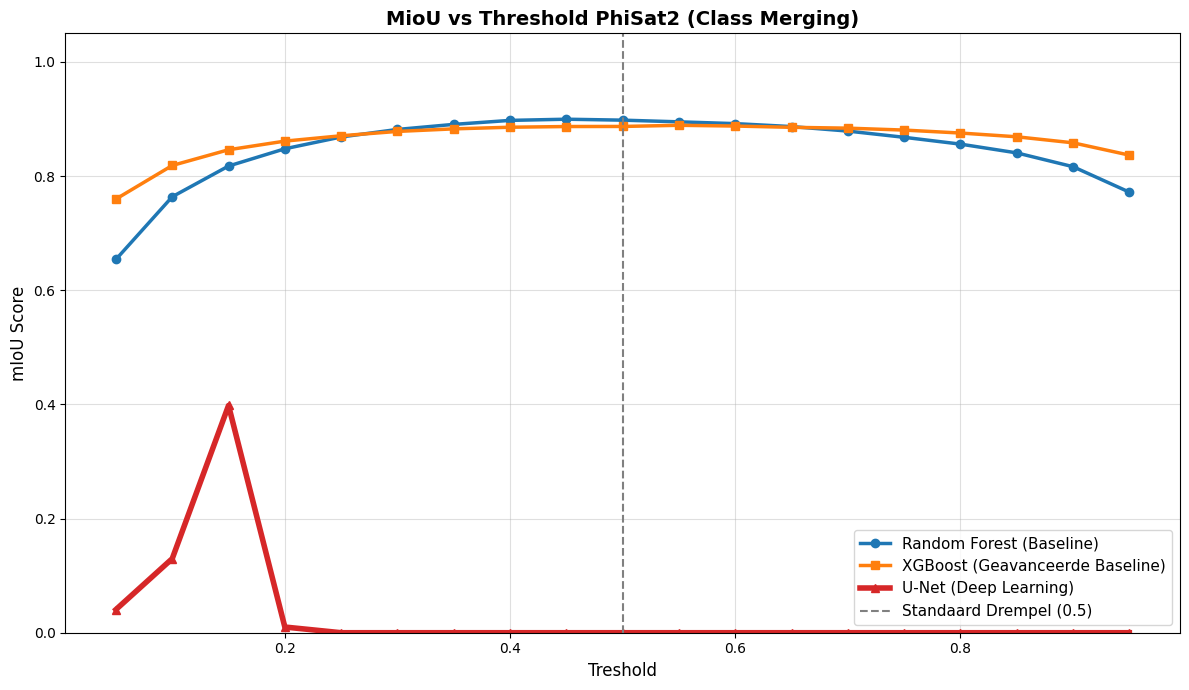

In [2]:
bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/PhiSat2'
thresholds = np.linspace(0.05, 0.95, 19)

plt.figure(figsize=(12, 7))

models = {
    'Random Forest (Baseline)': ('y_test_masks.npy', 'y_pred_probs_fire_rf.npy', 'tab:blue', 'o', 2.5),
    'XGBoost (Geavanceerde Baseline)': ('y_test_masks.npy', 'y_pred_probs_fire_xgb.npy', 'tab:orange', 's', 2.5),
    'U-Net (Deep Learning)': ('y_test_masks_unet.npy', 'y_pred_probs_fire_unet.npy', 'tab:red', '^', 4)
}

for name, (true_file, prob_file, color, marker, lw) in models.items():
    pad_true = os.path.join(bewerkte_data_dir, true_file)
    pad_prob = os.path.join(bewerkte_data_dir, prob_file)
    
    if os.path.exists(pad_true) and os.path.exists(pad_prob):
        y_true_raw = np.load(pad_true)
        probs = np.load(pad_prob)
        
        # === DE CLASS MERGING ===
        y_true_merged = (y_true_raw == 1).astype(int)

        mious = [jaccard_score(y_true_merged, (probs >= t).astype(int), zero_division=0) for t in thresholds]
        
        plt.plot(thresholds, mious, label=f'{name}', linewidth=lw, marker=marker, color=color)
    else:
        print(f"Files not found for {name}")

plt.axvline(0.5, color='gray', linestyle='--', label='Standaard Drempel (0.5)')
plt.title('MioU vs Threshold PhiSat2 (Class Merging)', fontsize=14, fontweight='bold')
plt.xlabel('Treshold', fontsize=12)
plt.ylabel('mIoU Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.ylim(0.0, 1.05) 
plt.tight_layout()
plt.show()